# 04 — Feature Engineering

**AttriSense · Employee Attrition Prediction & Analytics System**

---

## Purpose

Raw HR fields do not always capture the dynamics HR teams care about — career stagnation, pay relative to peers, or burnout risk. This notebook creates **eight derived features**, each grounded in a business hypothesis from EDA.

**Principles:**
- Every feature has a documented formula and business explanation
- No arbitrary transforms (no polynomial age terms, no random ratios)
- Feature importance evaluated before modeling
- Redundant features removed only when correlation **and** importance justify it
- Random seed fixed at `42` for reproducibility

**Input:** `data/processed/employee_attrition_cleaned.parquet`  
**Outputs:** `employee_attrition_featured.parquet`, `models/selected_features.json`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from attrisense.config import load_config
from attrisense.data import (
    engineered_feature_catalog,
    find_redundant_pairs,
    load_processed_data,
    run_feature_engineering_pipeline,
)

pd.set_option("display.max_colwidth", 100)
config = load_config()
RANDOM_STATE = config.random_state

df = load_processed_data(config)
print(f"Cleaned data: {df.shape[0]:,} rows × {df.shape[1]} columns")

Cleaned data: 1,470 rows × 32 columns


## 1. Engineered Feature Catalog

Each feature below addresses a specific HR question identified during EDA. None are created without a documented business rationale.

In [2]:
catalog = engineered_feature_catalog()
catalog

,feature,formula,business_explanation
0,promotion_stagnation_ratio,"YearsSinceLastPromotion / max(YearsAtCompany, 1)",Share of company tenure spent without a promotion. High values indicate career stagnation — a re...
1,role_tenure_share,"YearsInCurrentRole / max(YearsAtCompany, 1)",Fraction of company tenure spent in the current role. Low values may indicate frequent internal ...
2,manager_tenure_share,"YearsWithCurrManager / max(YearsAtCompany, 1)",Proportion of company tenure spent with the current manager. Manager relationship length is link...
3,income_vs_role_median,MonthlyIncome / median(MonthlyIncome | JobRole),Pay relative to the median for the same job role. Values below 1.0 suggest below-peer compensati...
4,compensation_per_experience,"MonthlyIncome / max(TotalWorkingYears, 1)",Monthly pay per year of total work experience. Captures whether compensation keeps pace with car...
5,avg_satisfaction_score,"mean(JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, WorkLifeBalance)",Composite engagement score across four satisfaction dimensions. EDA showed each dimension predic...
6,burnout_risk_flag,OverTime == 'Yes' AND WorkLifeBalance <= 2,Binary flag combining overtime and poor work-life balance — the two strongest operational attrit...
7,job_stability_index,"TotalWorkingYears / max(NumCompaniesWorked, 1)",Average years per employer across the employee's career. Higher values indicate stable career pa...


### Feature-to-EDA mapping

| Feature | EDA signal it captures |
|---------|------------------------|
| `promotion_stagnation_ratio` | Tenure and promotion variables correlate with attrition |
| `role_tenure_share` | Career progression within the company |
| `manager_tenure_share` | `YearsWithCurrManager` correlates with retention |
| `income_vs_role_median` | Lower income → higher attrition; role-relative pay matters |
| `compensation_per_experience` | Pay not keeping pace with career length |
| `avg_satisfaction_score` | All four satisfaction dimensions predict departure |
| `burnout_risk_flag` | Overtime (30.5%) and poor WLB (31.2%) are top attrition drivers |
| `job_stability_index` | `NumCompaniesWorked` reflects job-hopping history |

## 2. Apply Feature Engineering

The pipeline fits role-level income medians, computes all eight features, and appends them to the cleaned dataset. Role medians are saved to `models/feature_engineering_state.joblib` for consistent inference.

In [3]:
featured, report = run_feature_engineering_pipeline(df, config=config, save_artifacts=True)

eng_cols = report.engineered_columns
print(f"Featured dataset : {report.output_shape[0]:,} rows × {report.output_shape[1]} columns")
print(f"New features     : {len(eng_cols)}")
print(f"Saved to         : {report.output_paths['featured']}")

featured[eng_cols].describe().T

Featured dataset : 1,470 rows × 40 columns
New features     : 8
Saved to         : D:\Fun\AttriSense-Employee-Attrition-Prediction\data\processed\employee_attrition_featured.parquet


,count,mean,std,min,25%,50%,75%,max
promotion_stagnation_ratio,1470.0,0.290232,0.340521,0.000000,0.000000,0.166667,0.500000,1.000000
role_tenure_share,1470.0,0.578220,0.331966,0.000000,0.352500,0.666667,0.833333,1.000000
manager_tenure_share,1470.0,0.558626,0.334732,0.000000,0.333333,0.666667,0.800000,1.000000
income_vs_role_median,1470.0,1.104172,0.398415,0.349437,0.822791,1.000000,1.291753,3.467507
compensation_per_experience,1470.0,718.266313,485.321703,100.050000,417.800000,602.815126,849.945652,2994.000000
avg_satisfaction_score,1470.0,2.730952,0.505815,1.000000,2.500000,2.750000,3.000000,4.000000
burnout_risk_flag,1470.0,0.085714,0.280037,0.000000,0.000000,0.000000,0.000000,1.000000
job_stability_index,1470.0,6.132135,5.646442,0.000000,2.035714,4.633333,9.000000,40.000000


### Validate engineered features against attrition

Quick sanity check: engineered features should show different attrition rates across their value ranges.

In [4]:
featured["Attrition_Yes"] = (featured[config.target_column] == config.positive_class).astype(int)

checks = []
for col in ["burnout_risk_flag", "avg_satisfaction_score", "income_vs_role_median"]:
    if col == "burnout_risk_flag":
        grp = featured.groupby(col)["Attrition_Yes"].mean() * 100
        checks.append(f"{col}: no burnout={grp.get(0, 0):.1f}%, burnout={grp.get(1, 0):.1f}%")
    elif col == "avg_satisfaction_score":
        low = featured[featured[col] <= 2]["Attrition_Yes"].mean() * 100
        high = featured[featured[col] >= 3.5]["Attrition_Yes"].mean() * 100
        checks.append(f"{col}: low (≤2)={low:.1f}%, high (≥3.5)={high:.1f}%")
    else:
        below = featured[featured[col] < 1.0]["Attrition_Yes"].mean() * 100
        above = featured[featured[col] >= 1.0]["Attrition_Yes"].mean() * 100
        checks.append(f"{col}: below peer median={below:.1f}%, at/above={above:.1f}%")

for line in checks:
    print(line)

burnout_risk_flag: no burnout=14.5%, burnout=33.3%
avg_satisfaction_score: low (≤2)=31.3%, high (≥3.5)=9.5%
income_vs_role_median: below peer median=18.2%, at/above=14.1%


**Sanity check:** Engineered features show expected direction — burnout flag, low satisfaction, and below-peer pay all associate with higher attrition. The features carry signal beyond their raw inputs.

## 3. Feature Importance Evaluation

A Random Forest (`n_estimators=300`, `class_weight='balanced'`, `random_state=42`) ranks all base and engineered features. Nominal columns are one-hot encoded for this evaluation.

**Business question:** *Which features — raw or engineered — contribute most to predicting attrition?*

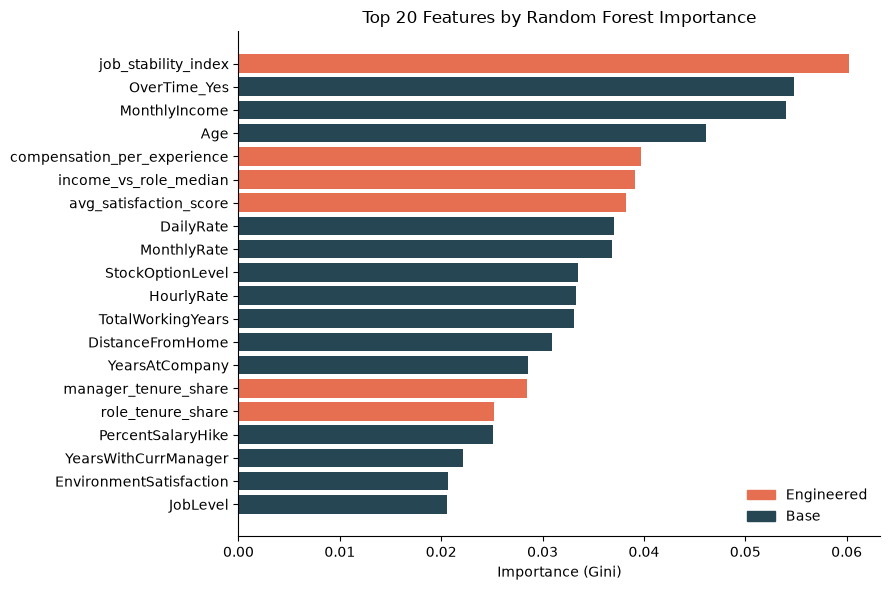

,feature,importance
0,job_stability_index,0.060274
1,OverTime_Yes,0.054845
2,MonthlyIncome,0.053994
3,Age,0.046090
4,compensation_per_experience,0.039687
5,income_vs_role_median,0.039142
6,avg_satisfaction_score,0.038261
7,DailyRate,0.037055
8,MonthlyRate,0.036814
9,StockOptionLevel,0.033458


In [5]:
importance = report.importance_ranking
top_n = 20
top = importance.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#e76f51" if f in eng_cols else "#264653" for f in top["feature"]]
ax.barh(top["feature"][::-1], top["importance"][::-1], color=colors[::-1])
ax.set_xlabel("Importance (Gini)")
ax.set_title(f"Top {top_n} Features by Random Forest Importance")
ax.spines[["top", "right"]].set_visible(False)

# Legend
from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(color="#e76f51", label="Engineered"),
        Patch(color="#264653", label="Base"),
    ],
    frameon=False,
    loc="lower right",
)
plt.tight_layout()
plt.show()

importance.head(15)

**Interpretation:** Three engineered features rank in the top 10: `job_stability_index` (#1), `compensation_per_experience` (#5), and `income_vs_role_median` (#6). `OverTime_Yes` and `MonthlyIncome` remain strong base features. Engineering added measurable signal — particularly job stability and compensation-relative metrics.

## 4. Redundancy Analysis

Features with |Pearson r| ≥ 0.92 are flagged for review. Removal happens only when one member of the pair has **strictly lower** Random Forest importance — the kept feature must carry more predictive signal.

**Business question:** *Are we feeding the model duplicate information?*

In [6]:
all_features = config.model_feature_columns + eng_cols
pairs = find_redundant_pairs(
    featured,
    all_features,
    threshold=config.feature_engineering.correlation_threshold,
)

print(f"Correlation threshold: {config.feature_engineering.correlation_threshold}")
print(f"Redundant pairs found : {len(pairs)}")

if pairs.empty:
    print("No pairs exceeded the threshold.")
else:
    display_pairs = pairs.sort_values("correlation", ascending=False)
    display_pairs

Correlation threshold: 0.92
Redundant pairs found : 1


## 5. Redundancy Resolution

For each redundant pair, the lower-importance feature is dropped. Justifications are logged and saved to `models/selected_features.json`.

In [7]:
print(f"Features selected for modeling : {len(report.selected_features)}")
print(f"Features dropped               : {len(report.dropped_features)}")
print()

if report.dropped_features:
    for decision in report.redundancy_decisions:
        print(f"DROP  {decision.dropped_feature}")
        print(f"KEEP  {decision.kept_feature}")
        print(f"      {decision.reason}")
        print()
else:
    print("No features dropped — no redundant pairs met both criteria.")

pd.DataFrame([
    {
        "dropped": d.dropped_feature,
        "kept": d.kept_feature,
        "correlation": d.correlation,
        "dropped_importance": round(d.dropped_importance, 4),
        "kept_importance": round(d.kept_importance, 4),
    }
    for d in report.redundancy_decisions
])

Features selected for modeling : 37
Features dropped               : 1

DROP  JobLevel
KEEP  MonthlyIncome
      |r|=0.950 with 'MonthlyIncome' (importance 0.0540 vs 0.0206)



,dropped,kept,correlation,dropped_importance,kept_importance
0,JobLevel,MonthlyIncome,0.9503,0.0206,0.054


**Interpretation:** `JobLevel` and `MonthlyIncome` correlate at r = 0.95 — expected, since higher job levels command higher pay. `MonthlyIncome` has greater importance (0.054 vs 0.021), so `JobLevel` is dropped. Income is the more direct compensation signal for attrition; job level adds little beyond what income already captures.

All other base and engineered features are retained — including compensation columns (`DailyRate`, `HourlyRate`, `MonthlyRate`) which are **not** highly correlated with `MonthlyIncome` in this dataset.

## 6. Final Feature Set Summary

In [8]:
summary = pd.DataFrame({"feature": report.selected_features})
summary["category"] = summary["feature"].apply(
    lambda f: "Engineered" if f in eng_cols else "Base"
)

print(f"Total modeling features: {len(report.selected_features)}")
print(f"  Engineered            : {(summary['category'] == 'Engineered').sum()}")
print(f"  Base                  : {(summary['category'] == 'Base').sum()}")
print()
print("Artifacts saved:")
for key, path in report.output_paths.items():
    print(f"  {key}: {path}")

summary.sort_values(["category", "feature"]).reset_index(drop=True)

Total modeling features: 37
  Engineered            : 8
  Base                  : 29

Artifacts saved:
  featured: D:\Fun\AttriSense-Employee-Attrition-Prediction\data\processed\employee_attrition_featured.parquet
  state: D:\Fun\AttriSense-Employee-Attrition-Prediction\models\feature_engineering_state.joblib
  selected_features: D:\Fun\AttriSense-Employee-Attrition-Prediction\models\selected_features.json


,feature,category
0,Age,Base
1,BusinessTravel,Base
2,DailyRate,Base
3,Department,Base
4,DistanceFromHome,Base
5,Education,Base
6,EducationField,Base
7,EnvironmentSatisfaction,Base
8,Gender,Base
9,HourlyRate,Base


**Next step:** Model building using `models/selected_features.json` and `employee_attrition_featured.parquet`. The modeling notebook will fit encoders on the training split only to prevent data leakage.